In [22]:
from rdkit.Chem import AllChem, DataStructs
from rdkit import Chem
import pandas as pd
import numpy as np
import os
import umap
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

In [9]:
def smiles_to_morgan_fp(smiles: str, n_bits: int = 1024, radius: int = 2) -> np.ndarray:
    """
    Converts a SMILES string to a Morgan fingerprint.
    """
    mol = Chem.MolFromSmiles(smiles)    
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return np.array(fp)

In [15]:
# Get actives and inactives
df = pd.read_csv('../output/mtuberculosis/013a_raw_tasks_ORG/3_all_pchembl_value_6.csv')
actives = df[df['pchembl_value_6'] == 1]['smiles'].tolist()
inactives = pd.read_csv("/home/acomajuncosa/Downloads/chembl_compounds.tsv", sep='\t', low_memory=False)
inactives = inactives[(~inactives['Smiles'].isna()) & (inactives['Type'] == 'Small molecule')]['Smiles'].tolist()
print("Actives: " + str(len(actives)))
print("Inactives: " + str(len(inactives)))

Actives: 5499
Inactives: 1915466


In [20]:
# Fix random seed
np.random.seed(42)

# Choose 2*len(actives) inactives
N = len(actives)
selected_actives = actives
selected_inactives = np.random.choice(inactives, 2 * N, replace=False).tolist()
print("Actives: " + str(len(selected_actives)))
print("Inactives: " + str(len(selected_inactives)))

# Get ECFPs
print("Calculating ECFPs...")
actives_smiles = list(selected_actives)
inactives_smiles = list(selected_inactives)
selected_actives = [smiles_to_morgan_fp(i) for i in selected_actives]
selected_inactives = [smiles_to_morgan_fp(i) for i in selected_inactives]

# Create matrices
X = np.array(selected_actives + selected_inactives)
Y = np.array([1]*len(selected_actives) + [0]*len(selected_inactives))
print("Matrix shapes:")
print(X.shape, Y.shape)

Actives: 5499
Inactives: 10998
Calculating ECFPs...
Matrix shapes:
(16497, 1024) (16497,)


In [21]:
# Reduce to 2D - umap
reducer = umap.UMAP()
embedding_umap = reducer.fit_transform(X)

# Reduce to 2D - tSNE
tsne = TSNE(n_components=2, random_state=42, n_jobs=8)
embedding_tsne = tsne.fit_transform(X)

In [24]:
ind_act = np.where(Y == 1)[0]
ind_inact = np.where(Y == 0)[0]

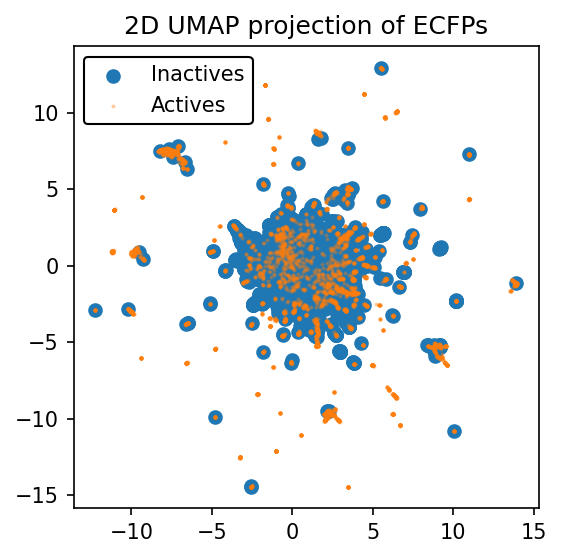

In [25]:
# Plot
plt.figure(figsize=(4,4))
plt.scatter(embedding_umap[ind_inact][:,0], embedding_umap[ind_inact][:,1], label='Inactives')
plt.scatter(embedding_umap[ind_act][:,0], embedding_umap[ind_act][:,1], alpha=0.3, label='Actives', s=1)
plt.legend(loc='upper left', framealpha=1, edgecolor='k')
plt.title("2D UMAP projection of ECFPs")
plt.show()

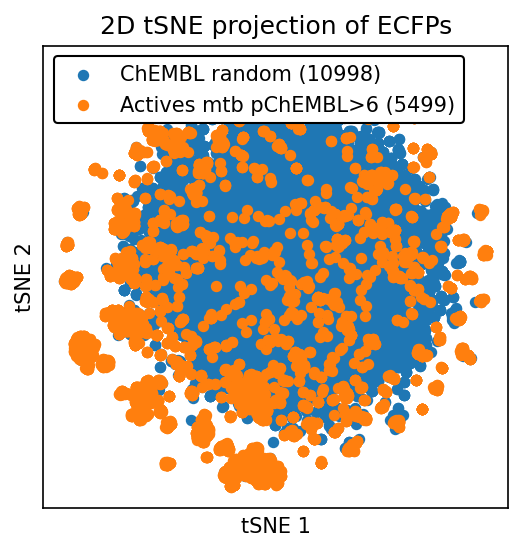

In [32]:
# Plot
plt.figure(figsize=(4,4))
plt.scatter(embedding_tsne[ind_inact][:,0], embedding_tsne[ind_inact][:,1], label=f'ChEMBL random ({len(ind_inact)})', s=20)
plt.scatter(embedding_tsne[ind_act][:,0], embedding_tsne[ind_act][:,1], alpha=1, label=f'Actives mtb pChEMBL>6 ({len(ind_act)})', s=20)
plt.legend(loc='upper left', framealpha=1, edgecolor='k')
plt.title("2D tSNE projection of ECFPs")
plt.xlabel("tSNE 1")
plt.ylabel("tSNE 2")
plt.xticks([])
plt.yticks([])
plt.show()